# Computer Vision Portfolio Project: Semantic Segmentation & Object Detection

[![Python](https://img.shields.io/badge/Python-3.10%2B-blue)](https://www.python.org/)
[![PyTorch](https://img.shields.io/badge/PyTorch-2.x-EE4C2C)](https://pytorch.org/)
[![Ultralytics](https://img.shields.io/badge/Ultralytics-YOLOv8-00FFFF)](https://docs.ultralytics.com/)
[![License](https://img.shields.io/badge/License-MIT-green)](LICENSE)

This project demonstrates two core competencies in modern computer vision:

1. **Semantic Segmentation** — a from-scratch PyTorch implementation of the **U-Net** architecture, trained end-to-end on a synthetic dataset, showcasing a solid understanding of encoder-decoder design, skip connections, loss functions (BCE + Dice), and evaluation metrics (IoU / Dice).
2. **Object Detection** — an end-to-end fine-tuning and inference pipeline built on **YOLOv8** (via the Ultralytics library), including training-curve analysis and applying the resulting model to real-world video data.

Together, these two parts cover the two dominant paradigms in dense visual understanding: pixel-level classification (segmentation) and instance-level localization (detection).

## Project Structure

- **Part 1 — U-Net from Scratch:**
  - Architecture design (with dynamic crop/pad handling for arbitrary input sizes) and a shape-correctness sanity check.
  - A lightweight, fully synthetic dataset generator so the whole pipeline is runnable end-to-end with zero external downloads.
  - A complete training loop (Combined BCE + Dice loss, IoU / Dice metrics, `tqdm` progress bars).
  - Training-curve visualization and qualitative predictions (`Image | Ground Truth | Prediction`).
- **Part 2 — YOLOv8 Fine-Tuning & Video Inference:** Model setup, fine-tuning on `coco8.yaml`, training-curve visualization, robust inference on a traffic video, and visualizing the detected bounding boxes directly in the notebook.


## Requirements / Dependencies

This notebook relies on the following core libraries:

| Library | Purpose |
|---|---|
| `torch` / `torchvision` | Tensor operations and building/training the U-Net architecture |
| `ultralytics` | YOLOv8 model loading, fine-tuning, and inference |
| `opencv-python` (`cv2`) | Synthetic data generation, video I/O, and frame-level image processing |
| `matplotlib` | Displaying sample frames, masks, and training curves inline |
| `numpy` | Array manipulation |
| `pandas` | Parsing YOLOv8 training logs (`results.csv`) for curve plotting |
| `tqdm` | Training progress bars |

Install any missing dependencies with:

```bash
pip install torch torchvision ultralytics opencv-python matplotlib numpy pandas tqdm
```

> **Note:** A CUDA-capable GPU is recommended for faster training and inference but is not required — all code below is written to be device-agnostic and will fall back to CPU automatically.


In [1]:
# Verify that the required libraries are installed and importable.
import importlib

required_packages = ["torch", "torchvision", "ultralytics", "cv2", "matplotlib", "numpy", "pandas", "tqdm"]
missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]

if missing:
    print(f"Missing packages: {missing}. Install them with 'pip install <package>' before proceeding.")
else:
    print("All required dependencies are installed.")


Missing packages: ['ultralytics']. Install them with 'pip install <package>' before proceeding.


## Reproducibility

To make results deterministic and easy to compare across runs, we fix the random seed for every source of randomness used in this notebook (Python's `random`, `numpy`, and `torch`/CUDA).


In [2]:
import random
import numpy as np
import torch


def seed_everything(seed: int = 42) -> None:
    """Seeds all relevant random number generators for reproducibility.

    Args:
        seed: The seed value to use across Python's ``random``, ``numpy``,
            and ``torch`` (CPU and CUDA).
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Favor determinism over raw speed for reproducible benchmarking.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
seed_everything(SEED)
print(f"Global random seed set to {SEED}.")


Global random seed set to 42.


## Part 1: U-Net for Semantic Segmentation

[U-Net](https://arxiv.org/abs/1505.04597) is a fully convolutional encoder-decoder architecture originally designed for biomedical image segmentation. Its defining characteristic is the use of **skip connections** that concatenate high-resolution encoder feature maps with the corresponding decoder feature maps, allowing the network to combine coarse, semantic information with fine, spatial detail.

The architecture consists of two symmetric paths:

- **Contracting path (encoder):** a sequence of convolutional blocks and max-pooling operations that progressively reduce spatial resolution while increasing feature depth, capturing contextual information.
- **Expansive path (decoder):** a sequence of transposed convolutions and convolutional blocks that progressively restore spatial resolution, using skip connections to recover fine-grained spatial detail lost during downsampling.

This section implements the architecture from first principles using core PyTorch primitives (`nn.Conv2d`, `nn.MaxPool2d`, `nn.ConvTranspose2d`), trains it on a synthetic dataset, and evaluates it with standard segmentation metrics.


In [3]:
import torch.nn as nn
import torch.nn.functional as F
from typing import List, Tuple, Dict


### 1.1 Device Configuration

All tensors and models in this notebook are mapped explicitly to the available compute device, ensuring the code runs seamlessly on both CPU-only and GPU-accelerated environments.


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### 1.2 The Double Convolution Block

The `DoubleConv` block is the fundamental building unit reused throughout both the encoder and decoder. It applies two consecutive `3x3` convolutions, each followed by batch normalization and a ReLU activation. Padding is set to `1` so that spatial dimensions are preserved across the convolution, leaving all downsampling/upsampling to the dedicated pooling and transposed-convolution layers.


In [5]:
class DoubleConv(nn.Module):
    """Two consecutive (Conv2d -> BatchNorm2d -> ReLU) blocks.

    This module is the core building block of the U-Net encoder and decoder.
    Padding is fixed to 1 so that the spatial resolution of the input is
    preserved through both convolutions.

    Attributes:
        double_conv: A sequential container holding the two convolutional
            sub-blocks.
    """

    def __init__(self, in_channels: int, out_channels: int) -> None:
        """Initializes the DoubleConv block.

        Args:
            in_channels: Number of channels in the input feature map.
            out_channels: Number of channels produced by both convolutions.
        """
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Applies the double convolution block.

        Args:
            x: Input tensor of shape ``(N, in_channels, H, W)``.

        Returns:
            Output tensor of shape ``(N, out_channels, H, W)``.
        """
        return self.double_conv(x)


### 1.3 The U-Net Architecture

The full `UNet` module assembles four `DoubleConv` + max-pooling stages in the encoder, a bottleneck, and four symmetric transposed-convolution + `DoubleConv` stages in the decoder. Skip connections carry encoder feature maps directly into the corresponding decoder stage via channel-wise concatenation.

**Handling arbitrary input sizes.** Each `MaxPool2d(2)` halves the spatial resolution, and each `ConvTranspose2d(kernel_size=2, stride=2)` doubles it back. This only cancels out exactly when height and width are divisible by `2^4 = 16`. For an input size that is *not* a multiple of 16 (e.g. `255x255` instead of `256x256`), integer-division rounding can leave a one-pixel mismatch between an upsampled decoder feature map and the corresponding encoder skip connection, which would otherwise crash `torch.cat`. The `_align` helper below center-crops or zero-pads the upsampled tensor so its spatial dimensions always match the skip connection exactly, letting the network run on **any** input resolution without manual resizing.


In [6]:
class UNet(nn.Module):
    """A standard U-Net architecture for semantic segmentation.

    Implements the classic encoder-decoder design with skip connections
    described in Ronneberger et al. (2015), "U-Net: Convolutional Networks
    for Biomedical Image Segmentation".

    Attributes:
        inc: Initial DoubleConv block applied to the raw input.
        down1-down4: Encoder stages (MaxPool2d followed by DoubleConv).
        up1_transpose-up4_transpose: Decoder upsampling layers.
        up1_conv-up4_conv: Decoder DoubleConv blocks applied after
            concatenating the skip connection.
        outc: Final 1x1 convolution mapping to the desired number of
            output classes.
    """

    def __init__(self, in_channels: int = 3, num_classes: int = 2) -> None:
        """Initializes the U-Net.

        Args:
            in_channels: Number of channels in the input image (e.g., 3 for RGB).
            num_classes: Number of output segmentation classes.
        """
        super().__init__()

        # --- Encoder (downsampling path) ---
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))

        # --- Bottleneck ---
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        # --- Decoder (upsampling path) ---
        self.up1_transpose = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up1_conv = DoubleConv(1024, 512)

        self.up2_transpose = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up2_conv = DoubleConv(512, 256)

        self.up3_transpose = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up3_conv = DoubleConv(256, 128)

        self.up4_transpose = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up4_conv = DoubleConv(128, 64)

        # --- Output projection ---
        self.outc = nn.Conv2d(64, num_classes, kernel_size=1)

    @staticmethod
    def _align(upsampled: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        """Center-crops or zero-pads ``upsampled`` to match ``skip``'s H/W.

        Handles the off-by-one spatial mismatches that occur when the input
        image's height/width is not an exact multiple of 16, which would
        otherwise make ``torch.cat`` raise a shape-mismatch error.

        Args:
            upsampled: Decoder feature map produced by a transposed
                convolution, shape ``(N, C, H1, W1)``.
            skip: Corresponding encoder feature map, shape ``(N, C, H2, W2)``.

        Returns:
            ``upsampled`` resized (via center crop and/or pad) to shape
            ``(N, C, H2, W2)``.
        """
        diff_h = skip.size(2) - upsampled.size(2)
        diff_w = skip.size(3) - upsampled.size(3)

        if diff_h != 0 or diff_w != 0:
            # Pad when the upsampled map is smaller, crop when it's larger.
            upsampled = F.pad(
                upsampled,
                [
                    diff_w // 2, diff_w - diff_w // 2,
                    diff_h // 2, diff_h - diff_h // 2,
                ],
            )
        return upsampled

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Runs a forward pass through the U-Net.

        Args:
            x: Input tensor of shape ``(N, in_channels, H, W)``. Height and
                width may be arbitrary; they are not required to be
                divisible by 16 thanks to the ``_align`` crop/pad step.

        Returns:
            Logits tensor of shape ``(N, num_classes, H, W)``.
        """
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)  # Bottleneck

        # Decoder, stage 1
        x_up1 = self._align(self.up1_transpose(x5), x4)
        x_out1 = self.up1_conv(torch.cat([x_up1, x4], dim=1))

        # Decoder, stage 2
        x_up2 = self._align(self.up2_transpose(x_out1), x3)
        x_out2 = self.up2_conv(torch.cat([x_up2, x3], dim=1))

        # Decoder, stage 3
        x_up3 = self._align(self.up3_transpose(x_out2), x2)
        x_out3 = self.up3_conv(torch.cat([x_up3, x2], dim=1))

        # Decoder, stage 4
        x_up4 = self._align(self.up4_transpose(x_out3), x1)
        x_out4 = self.up4_conv(torch.cat([x_up4, x1], dim=1))

        # Output projection to class logits
        logits = self.outc(x_out4)
        return logits


### 1.4 Architecture Validation

Before using the model for training, we run a lightweight forward-pass sanity check with two inputs: a `256x256` image (a clean multiple of 16) and a `255x255` image (deliberately *not* a multiple of 16) to confirm the `_align` crop/pad logic makes the network robust to arbitrary input dimensions.


In [7]:
print("Validating U-Net architecture...")

model = UNet(in_channels=3, num_classes=2).to(device)

for test_size in [256, 255]:
    dummy_image = torch.randn(1, 3, test_size, test_size, device=device)
    try:
        with torch.no_grad():
            output = model(dummy_image)
        expected_shape = (1, 2, test_size, test_size)
        assert output.shape == expected_shape, f"Expected shape {expected_shape}, got {tuple(output.shape)}"
        print(f"[{test_size}x{test_size}] Validation passed. Output shape: {tuple(output.shape)} on device: {output.device}")
    except Exception as exc:
        print(f"[{test_size}x{test_size}] Validation failed: {exc}")


Validating U-Net architecture...
[256x256] Validation passed. Output shape: (1, 2, 256, 256) on device: cuda:0
[255x255] Validation passed. Output shape: (1, 2, 255, 255) on device: cuda:0


### 1.5 Synthetic Segmentation Dataset

To keep this notebook **fully self-contained and runnable end-to-end without downloading any external data**, we generate a lightweight synthetic binary segmentation dataset on the fly: each sample is a textured background with a randomly placed, randomly sized geometric shape (circle, rectangle, or triangle) drawn on top. The ground-truth mask marks every pixel belonging to the shape. This is a standard toy setup for sanity-checking segmentation pipelines before moving on to real datasets.


In [8]:
import cv2


def _random_background(height: int, width: int) -> np.ndarray:
    """Creates a noisy RGB background with a smooth color gradient.

    Args:
        height: Output image height in pixels.
        width: Output image width in pixels.

    Returns:
        A ``(H, W, 3)`` uint8 array in RGB order.
    """
    base_color = np.random.randint(30, 200, size=3)
    gradient = np.linspace(0, 1, width, dtype=np.float32)
    background = np.tile(base_color, (height, width, 1)).astype(np.float32)
    background *= gradient[np.newaxis, :, np.newaxis] * 0.5 + 0.5
    noise = np.random.normal(0, 12, size=(height, width, 3))
    background = np.clip(background + noise, 0, 255).astype(np.uint8)
    return background


def generate_synthetic_sample(
    height: int = 128, width: int = 128
) -> Tuple[np.ndarray, np.ndarray]:
    """Generates one synthetic (image, mask) pair for binary segmentation.

    A single random shape (circle, rectangle, or triangle) of random size,
    position, and color is drawn on a noisy background. The mask is 1
    wherever the shape was drawn and 0 elsewhere.

    Args:
        height: Output image/mask height in pixels.
        width: Output image/mask width in pixels.

    Returns:
        A tuple ``(image, mask)`` where ``image`` is a ``(H, W, 3)`` uint8
        RGB array and ``mask`` is a ``(H, W)`` uint8 array with values in
        ``{0, 1}``.
    """
    image = _random_background(height, width)
    mask = np.zeros((height, width), dtype=np.uint8)

    shape_kind = np.random.choice(["circle", "rectangle", "triangle"])
    color = tuple(int(c) for c in np.random.randint(0, 255, size=3))
    margin = int(0.15 * min(height, width))
    cx = np.random.randint(margin, width - margin)
    cy = np.random.randint(margin, height - margin)
    size = np.random.randint(int(0.15 * min(height, width)), int(0.35 * min(height, width)))

    if shape_kind == "circle":
        cv2.circle(image, (cx, cy), size, color, thickness=-1)
        cv2.circle(mask, (cx, cy), size, 1, thickness=-1)
    elif shape_kind == "rectangle":
        pt1 = (cx - size, cy - size)
        pt2 = (cx + size, cy + size)
        cv2.rectangle(image, pt1, pt2, color, thickness=-1)
        cv2.rectangle(mask, pt1, pt2, 1, thickness=-1)
    else:  # triangle
        pts = np.array(
            [
                [cx, cy - size],
                [cx - size, cy + size],
                [cx + size, cy + size],
            ]
        )
        cv2.fillPoly(image, [pts], color)
        cv2.fillPoly(mask, [pts], 1)

    return image, mask


In [9]:
from torch.utils.data import Dataset, DataLoader, random_split


class SyntheticShapesDataset(Dataset):
    """A synthetic binary-segmentation dataset generated on the fly.

    Each call to ``__getitem__`` generates a fresh random (image, mask)
    pair via :func:`generate_synthetic_sample`, so no data is stored on
    disk. Images are normalized to ``[0, 1]`` and returned as
    ``(C, H, W)`` float tensors; masks are returned as ``(1, H, W)``
    float tensors with binary values.

    Attributes:
        length: Number of samples reported by ``__len__`` (samples are
            generated lazily, not pre-materialized).
        image_size: The ``(height, width)`` of generated samples.
    """

    def __init__(self, length: int, image_size: Tuple[int, int] = (128, 128)) -> None:
        """Initializes the dataset.

        Args:
            length: Number of samples this dataset should report/generate.
            image_size: ``(height, width)`` of each generated sample.
        """
        self.length = length
        self.image_size = image_size

    def __len__(self) -> int:
        return self.length

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Generates one synthetic sample.

        Args:
            idx: Sample index (unused beyond satisfying the ``Dataset`` API,
                since samples are generated randomly on each call).

        Returns:
            A tuple ``(image, mask)`` of float tensors with shapes
            ``(3, H, W)`` and ``(1, H, W)`` respectively.
        """
        height, width = self.image_size
        image, mask = generate_synthetic_sample(height, width)
        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask_tensor = torch.from_numpy(mask).unsqueeze(0).float()
        return image_tensor, mask_tensor


IMAGE_SIZE = (128, 128)
full_dataset = SyntheticShapesDataset(length=600, image_size=IMAGE_SIZE)
train_size = int(0.85 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")
print(f"Batches per epoch -> train: {len(train_loader)}, val: {len(val_loader)}")


Train samples: 510 | Val samples: 90
Batches per epoch -> train: 32, val: 6


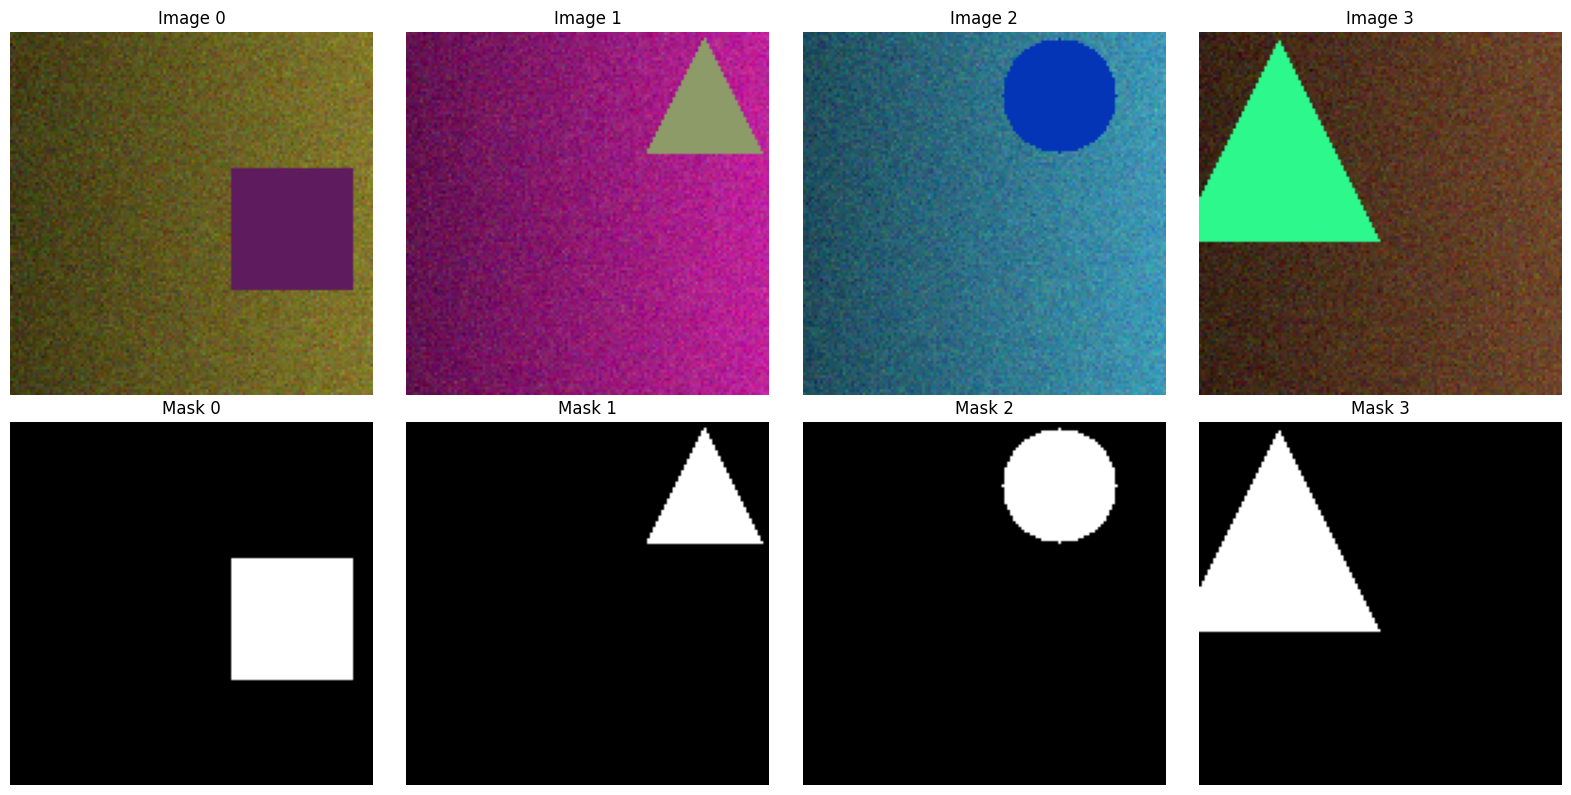

In [10]:
import matplotlib.pyplot as plt

# Preview a handful of raw synthetic samples before training.
preview_images, preview_masks = next(iter(train_loader))
num_preview = min(4, preview_images.size(0))

fig, axes = plt.subplots(2, num_preview, figsize=(4 * num_preview, 8))
for i in range(num_preview):
    axes[0, i].imshow(preview_images[i].permute(1, 2, 0).numpy())
    axes[0, i].set_title(f"Image {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(preview_masks[i, 0].numpy(), cmap="gray")
    axes[1, i].set_title(f"Mask {i}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


### 1.6 Loss Function & Evaluation Metrics

Binary segmentation is trained here with a **combined BCE + Dice loss**:

- **Binary Cross-Entropy (BCE)** provides a stable per-pixel classification signal.
- **Dice Loss** directly optimizes region overlap and is far less sensitive to foreground/background class imbalance than BCE alone (small shapes on a large background is exactly this scenario).

For evaluation we track **IoU (Intersection over Union)** and **Dice score**, the two standard overlap metrics for segmentation.


In [11]:
class DiceLoss(nn.Module):
    """Soft Dice loss for binary segmentation.

    Computes ``1 - Dice coefficient`` on sigmoid-activated logits, which is
    differentiable and directly optimizes mask overlap.
    """

    def __init__(self, smooth: float = 1.0) -> None:
        """Initializes the Dice loss.

        Args:
            smooth: Additive smoothing constant to avoid division by zero
                and stabilize gradients for empty masks/predictions.
        """
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """Computes the Dice loss.

        Args:
            logits: Raw model outputs, shape ``(N, 1, H, W)``.
            targets: Binary ground-truth masks, shape ``(N, 1, H, W)``.

        Returns:
            A scalar Dice loss tensor.
        """
        probs = torch.sigmoid(logits)
        probs_flat = probs.view(probs.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)

        intersection = (probs_flat * targets_flat).sum(dim=1)
        union = probs_flat.sum(dim=1) + targets_flat.sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()


class CombinedBCEDiceLoss(nn.Module):
    """Weighted sum of BCE-with-logits loss and Dice loss.

    Attributes:
        bce: The binary cross-entropy component.
        dice: The Dice loss component.
        bce_weight: Relative weight applied to the BCE term.
    """

    def __init__(self, bce_weight: float = 0.5) -> None:
        """Initializes the combined loss.

        Args:
            bce_weight: Weight in ``[0, 1]`` applied to the BCE term; the
                Dice term receives weight ``(1 - bce_weight)``.
        """
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """Computes the combined loss.

        Args:
            logits: Raw model outputs, shape ``(N, 1, H, W)``.
            targets: Binary ground-truth masks, shape ``(N, 1, H, W)``.

        Returns:
            A scalar loss tensor.
        """
        bce_loss = self.bce(logits, targets)
        dice_loss = self.dice(logits, targets)
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss


@torch.no_grad()
def iou_score(logits: torch.Tensor, targets: torch.Tensor, threshold: float = 0.5, eps: float = 1e-7) -> float:
    """Computes mean Intersection-over-Union over a batch.

    Args:
        logits: Raw model outputs, shape ``(N, 1, H, W)``.
        targets: Binary ground-truth masks, shape ``(N, 1, H, W)``.
        threshold: Probability threshold used to binarize predictions.
        eps: Small constant to avoid division by zero.

    Returns:
        The mean IoU across the batch as a Python float.
    """
    preds = (torch.sigmoid(logits) > threshold).float()
    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = (preds + targets).clamp(0, 1).sum(dim=(1, 2, 3))
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()


@torch.no_grad()
def dice_score(logits: torch.Tensor, targets: torch.Tensor, threshold: float = 0.5, eps: float = 1e-7) -> float:
    """Computes mean Dice coefficient over a batch.

    Args:
        logits: Raw model outputs, shape ``(N, 1, H, W)``.
        targets: Binary ground-truth masks, shape ``(N, 1, H, W)``.
        threshold: Probability threshold used to binarize predictions.
        eps: Small constant to avoid division by zero.

    Returns:
        The mean Dice score across the batch as a Python float.
    """
    preds = (torch.sigmoid(logits) > threshold).float()
    intersection = (preds * targets).sum(dim=(1, 2, 3))
    denom = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2 * intersection + eps) / (denom + eps)
    return dice.mean().item()


### 1.7 Training Loop

The model is re-instantiated for single-channel (binary) output and trained with `Adam`, the combined BCE + Dice loss, and per-epoch IoU / Dice tracking on the held-out validation split. `tqdm` progress bars report live batch-level loss during training.


In [12]:
from tqdm.auto import tqdm


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> float:
    """Runs one full training epoch.

    Args:
        model: The segmentation model to train.
        loader: DataLoader yielding ``(image, mask)`` batches.
        criterion: Loss function taking ``(logits, targets)``.
        optimizer: Optimizer used to update ``model``'s parameters.
        device: Device to run computation on.

    Returns:
        The mean training loss over the epoch.
    """
    model.train()
    running_loss = 0.0
    progress = tqdm(loader, desc="train", leave=False)
    for images, masks in progress:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        progress.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> Dict[str, float]:
    """Evaluates the model on a validation/test loader.

    Args:
        model: The segmentation model to evaluate.
        loader: DataLoader yielding ``(image, mask)`` batches.
        criterion: Loss function taking ``(logits, targets)``.
        device: Device to run computation on.

    Returns:
        A dict with keys ``"loss"``, ``"iou"``, and ``"dice"`` giving the
        mean metric values over the loader.
    """
    model.eval()
    running_loss, running_iou, running_dice = 0.0, 0.0, 0.0
    for images, masks in tqdm(loader, desc="val", leave=False):
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        loss = criterion(logits, masks)

        running_loss += loss.item() * images.size(0)
        running_iou += iou_score(logits, masks) * images.size(0)
        running_dice += dice_score(logits, masks) * images.size(0)

    n = len(loader.dataset)
    return {"loss": running_loss / n, "iou": running_iou / n, "dice": running_dice / n}


In [13]:
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3

seg_model = UNet(in_channels=3, num_classes=1).to(device)
criterion = CombinedBCEDiceLoss(bce_weight=0.5)
optimizer = torch.optim.Adam(seg_model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

history: Dict[str, List[float]] = {"train_loss": [], "val_loss": [], "val_iou": [], "val_dice": []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(seg_model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(seg_model, val_loader, criterion, device)
    scheduler.step(val_metrics["loss"])

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_iou"].append(val_metrics["iou"])
    history["val_dice"].append(val_metrics["dice"])

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} | val_loss={val_metrics['loss']:.4f} | "
        f"val_iou={val_metrics['iou']:.4f} | val_dice={val_metrics['dice']:.4f}"
    )

print("Training complete.")


train:   0%|          | 0/32 [00:00<?, ?it/s]

val:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 01/15 | train_loss=0.4237 | val_loss=1.9679 | val_iou=0.1882 | val_dice=0.3072


train:   0%|          | 0/32 [00:00<?, ?it/s]

val:   0%|          | 0/6 [00:00<?, ?it/s]

...

val:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 14/15 | train_loss=0.0047 | val_loss=0.0040 | val_iou=0.9975 | val_dice=0.9988


train:   0%|          | 0/32 [00:00<?, ?it/s]

val:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 15/15 | train_loss=0.0044 | val_loss=0.0037 | val_iou=0.9986 | val_dice=0.9993
Training complete.


### 1.8 Training Curves

Plotting the loss and evaluation metrics per epoch makes it easy to confirm the model is converging and to spot over/underfitting at a glance.


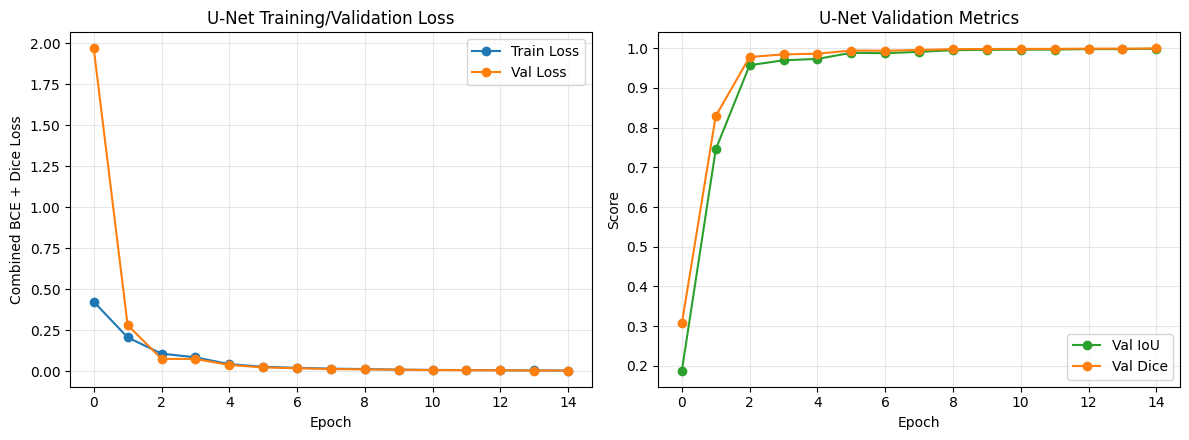

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(history["val_loss"], label="Val Loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Combined BCE + Dice Loss")
axes[0].set_title("U-Net Training/Validation Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["val_iou"], label="Val IoU", marker="o", color="tab:green")
axes[1].plot(history["val_dice"], label="Val Dice", marker="o", color="tab:orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("U-Net Validation Metrics")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 1.9 Qualitative Results

Finally, we visualize predictions side by side with the input image and ground-truth mask for a batch of validation samples: `Original Image | Ground Truth Mask | Predicted Mask`.


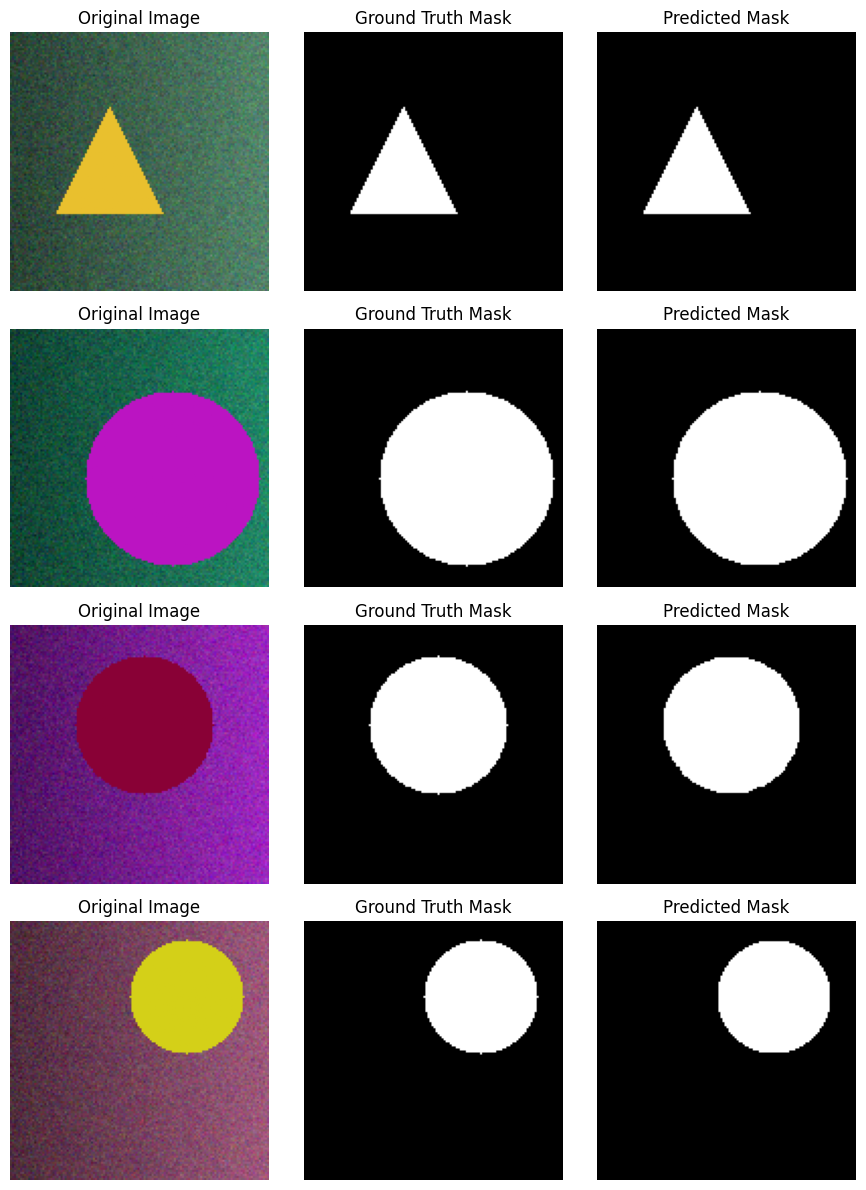

In [15]:
@torch.no_grad()
def visualize_predictions(model: nn.Module, loader: DataLoader, device: torch.device, num_samples: int = 4) -> None:
    """Plots (image, ground truth, prediction) triplets for qualitative review.

    Args:
        model: A trained segmentation model.
        loader: DataLoader to draw a batch of samples from.
        device: Device to run inference on.
        num_samples: Number of samples to display.
    """
    model.eval()
    images, masks = next(iter(loader))
    images, masks = images.to(device), masks.to(device)
    logits = model(images)
    preds = (torch.sigmoid(logits) > 0.5).float()

    num_samples = min(num_samples, images.size(0))
    fig, axes = plt.subplots(num_samples, 3, figsize=(9, 3 * num_samples))
    if num_samples == 1:
        axes = axes[np.newaxis, :]

    for i in range(num_samples):
        axes[i, 0].imshow(images[i].cpu().permute(1, 2, 0).numpy())
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(masks[i, 0].cpu().numpy(), cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(preds[i, 0].cpu().numpy(), cmap="gray")
        axes[i, 2].set_title("Predicted Mask")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()


visualize_predictions(seg_model, val_loader, device, num_samples=4)


## Part 2: YOLOv8 Fine-Tuning & Video Inference

While Part 1 demonstrates architecture-level understanding by implementing a segmentation network from scratch, real-world object detection pipelines are typically built on top of mature, production-grade libraries. This section uses [Ultralytics YOLOv8](https://docs.ultralytics.com/) to:

1. Load a pretrained YOLOv8 nano checkpoint.
2. Fine-tune it on the `coco8.yaml` dataset (a small 8-image subset of COCO used for pipeline validation).
3. Visualize the resulting training curves (box/class/DFL loss and mAP).
4. Run inference on a real-world traffic video, with robust error handling for file/network/GPU issues.
5. Visualize sample annotated frames directly in the notebook.


### 2.1 Environment Setup

This cell verifies the `ultralytics` installation and downloads a sample traffic video used for the inference demo in Section 2.4. Network and filesystem errors are caught explicitly so a failed download produces a clear, actionable message instead of an opaque traceback.


In [17]:
!pip install ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.5 MB/s eta 0:00:00


In [18]:
import os
import urllib.request
import urllib.error

from ultralytics import YOLO

print("Ultralytics YOLO successfully imported.")

# Sample traffic video used for the inference demo.
VIDEO_URL = "https://github.com/intel-iot-devkit/sample-videos/raw/master/car-detection.mp4"
VIDEO_PATH = "traffic_video.mp4"

if not os.path.exists(VIDEO_PATH):
    print(f"Downloading sample video to '{VIDEO_PATH}'...")
    try:
        urllib.request.urlretrieve(VIDEO_URL, VIDEO_PATH)
        print("Download complete.")
    except urllib.error.URLError as exc:
        print(f"Network error while downloading the sample video: {exc}")
        print("Check your internet connection, or manually place a video at "
              f"'{VIDEO_PATH}' before running Section 2.4.")
    except OSError as exc:
        print(f"Filesystem error while saving the sample video: {exc}")
else:
    print(f"'{VIDEO_PATH}' already exists locally. Skipping download.")


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics YOLO successfully imported.
Download complete.


### 2.2 Model Initialization & Fine-Tuning

We initialize a YOLOv8 nano (`yolov8n.pt`) model — the smallest and fastest variant in the YOLOv8 family, well suited for quick experimentation and edge deployment — and fine-tune it on `coco8.yaml` for a small number of epochs. This mirrors a typical transfer-learning workflow: start from COCO-pretrained weights and adapt them to a target dataset. Model loading is wrapped in a `try`/`except` block so a missing checkpoint file or a corrupted download fails with a clear message rather than a raw stack trace.


In [19]:
try:
    model_yolo = YOLO("yolov8n.pt")
    print("YOLOv8n checkpoint loaded successfully.")
except FileNotFoundError as exc:
    raise FileNotFoundError(
        "Could not locate the 'yolov8n.pt' checkpoint. Ultralytics normally "
        "auto-downloads it on first use -- verify your internet connection "
        f"and try again. Original error: {exc}"
    ) from exc
except Exception as exc:
    raise RuntimeError(f"Failed to initialize the YOLOv8 model: {exc}") from exc


YOLOv8n checkpoint loaded successfully.


In [20]:
# Fine-tune on the coco8.yaml dataset. Ultralytics handles device selection
# internally, but we still guard the call so an out-of-memory GPU error (or
# any other training-time failure) surfaces a clean, actionable message
# instead of aborting the whole notebook.
try:
    train_results = model_yolo.train(data="coco8.yaml", epochs=3, imgsz=640)
    print("Fine-tuning complete.")
except torch.cuda.OutOfMemoryError as exc:
    print(f"GPU ran out of memory during training: {exc}")
    print("Retrying on CPU with a smaller batch size...")
    torch.cuda.empty_cache()
    train_results = model_yolo.train(data="coco8.yaml", epochs=3, imgsz=640, device="cpu", batch=4)
except Exception as exc:
    print(f"Training failed: {exc}")
    raise


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False

### 2.3 Training Curve Visualization

Ultralytics writes a `results.csv` file to the run directory (`<save_dir>/results.csv`) containing per-epoch training/validation losses and mAP metrics. We parse it with `pandas` and plot the box/classification/DFL losses alongside `mAP50` and `mAP50-95` to visually confirm the fine-tuning run converged. This is wrapped defensively since the file's exact location depends on the Ultralytics version and run configuration.


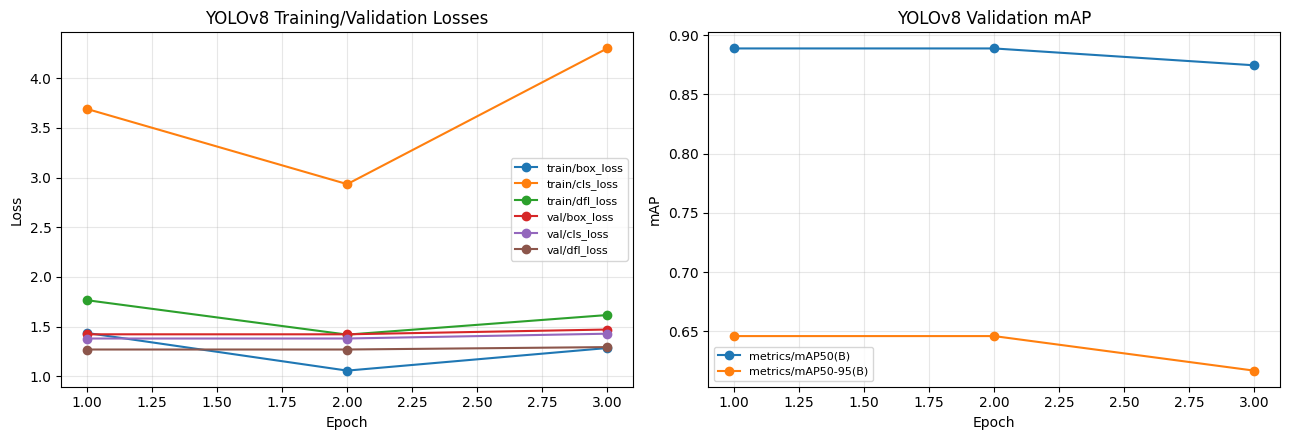

In [21]:
import pandas as pd


def plot_yolo_training_curves(train_results) -> None:
    """Plots YOLOv8 training loss and mAP curves from its results.csv log.

    Args:
        train_results: The object returned by ``model.train(...)``, used to
            locate the run's save directory.
    """
    try:
        save_dir = getattr(train_results, "save_dir", None)
        results_csv = os.path.join(str(save_dir), "results.csv") if save_dir else None

        if not results_csv or not os.path.exists(results_csv):
            print("Could not locate 'results.csv' for this run; skipping curve plot. "
                  "This can happen if training was interrupted or the Ultralytics "
                  "version stores logs in a different location.")
            return

        df = pd.read_csv(results_csv)
        df.columns = [c.strip() for c in df.columns]

        loss_cols = [c for c in df.columns if "loss" in c.lower()]
        map_cols = [c for c in df.columns if "map" in c.lower()]

        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

        for col in loss_cols:
            axes[0].plot(df["epoch"] if "epoch" in df.columns else df.index, df[col], label=col, marker="o")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].set_title("YOLOv8 Training/Validation Losses")
        axes[0].legend(fontsize=8)
        axes[0].grid(alpha=0.3)

        for col in map_cols:
            axes[1].plot(df["epoch"] if "epoch" in df.columns else df.index, df[col], label=col, marker="o")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("mAP")
        axes[1].set_title("YOLOv8 Validation mAP")
        axes[1].legend(fontsize=8)
        axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print(f"Could not plot training curves: {exc}")


plot_yolo_training_curves(train_results)


### 2.4 Inference on Video

With the fine-tuned model in hand, we run inference on the traffic video and persist the annotated output to disk. Passing `save=True` writes an annotated copy of the video to the `runs/detect/predict` directory. The call is wrapped in error handling that covers three common failure modes: a missing/undownloaded video file, GPU out-of-memory during inference, and any other runtime failure -- each falls back gracefully or reports a clear diagnostic instead of crashing the notebook.


In [22]:
results = []

if not os.path.exists(VIDEO_PATH):
    print(f"Video file '{VIDEO_PATH}' not found. Re-run Section 2.1 to download it, "
          "or place your own video at that path before running inference.")
else:
    print(f"Running inference on '{VIDEO_PATH}'...")
    try:
        results = model_yolo.predict(source=VIDEO_PATH, save=True)
        print(f"Inference complete. {len(results)} frames processed.")
        print("Annotated video saved under 'runs/detect/predict/'.")
    except torch.cuda.OutOfMemoryError as exc:
        print(f"GPU ran out of memory during inference: {exc}")
        print("Retrying inference on CPU...")
        torch.cuda.empty_cache()
        try:
            results = model_yolo.predict(source=VIDEO_PATH, save=True, device="cpu")
            print(f"CPU inference complete. {len(results)} frames processed.")
        except Exception as cpu_exc:
            print(f"CPU fallback also failed: {cpu_exc}")
    except FileNotFoundError as exc:
        print(f"Video file could not be opened: {exc}")
    except Exception as exc:
        print(f"Unexpected error during inference: {exc}")


Running inference on 'traffic_video.mp4'...

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/377) /content/traffic_video.mp4: 384x640 (no detections), 6.5ms
video 1/1 (frame 2/377) /content/traffic_video.mp4: 384x640 (no detections), 6.5ms
video 1/1 (frame 3/377) /content/traffic_video.mp4: 384x640 (no detections), 6.0ms
video 1/1 (frame 4/377) /content/traffic_video.mp4: 384x640 (no detections), 7.2ms
video 1/1 (frame 5/377) /content/traffic_video.mp4: 384x640 (no detections), 6.3ms

### 2.5 Visualizing Sample Detections

Frame-by-frame text logs are useful for debugging, but they don't convey what the model actually detected. The cell below samples a handful of frames from the inference results, draws bounding boxes and class labels using Ultralytics' built-in `.plot()` renderer, and displays them inline using `matplotlib`.


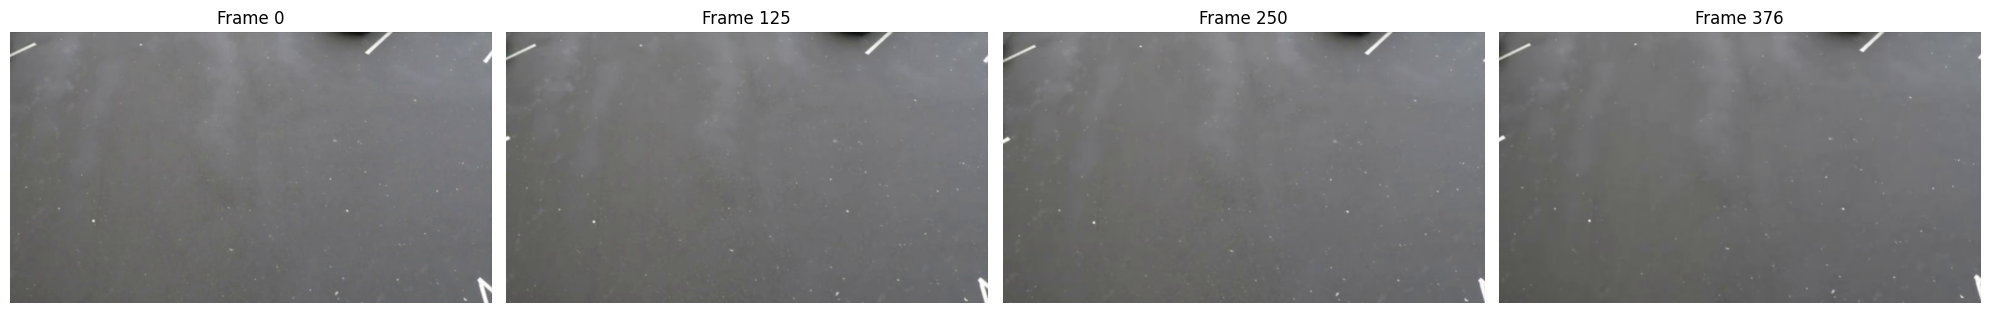

In [23]:
def display_sample_detections(results: list, num_samples: int = 4) -> None:
    """Displays a grid of sample frames with bounding boxes overlaid.

    Args:
        results: A list of Ultralytics ``Results`` objects, as returned by
            ``model.predict(...)``.
        num_samples: Number of frames to sample and display.
    """
    if not results:
        print("No results to display.")
        return

    total_frames = len(results)
    num_samples = min(num_samples, total_frames)
    sample_indices = np.linspace(0, total_frames - 1, num_samples, dtype=int)

    fig, axes = plt.subplots(1, num_samples, figsize=(5 * num_samples, 5))
    if num_samples == 1:
        axes = [axes]

    for ax, idx in zip(axes, sample_indices):
        # .plot() renders bounding boxes, class labels, and confidence
        # scores onto the frame, returning a BGR numpy array.
        annotated_frame_bgr = results[idx].plot()
        annotated_frame_rgb = annotated_frame_bgr[..., ::-1]  # BGR -> RGB

        ax.imshow(annotated_frame_rgb)
        ax.set_title(f"Frame {idx}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


display_sample_detections(results, num_samples=4)


### 2.6 (Optional) Reading Annotated Frames Directly with OpenCV

As an alternative to Ultralytics' built-in `.plot()` renderer, frames can also be pulled directly from the saved annotated video using `cv2`. This is useful when working with output artifacts rather than in-memory `Results` objects.


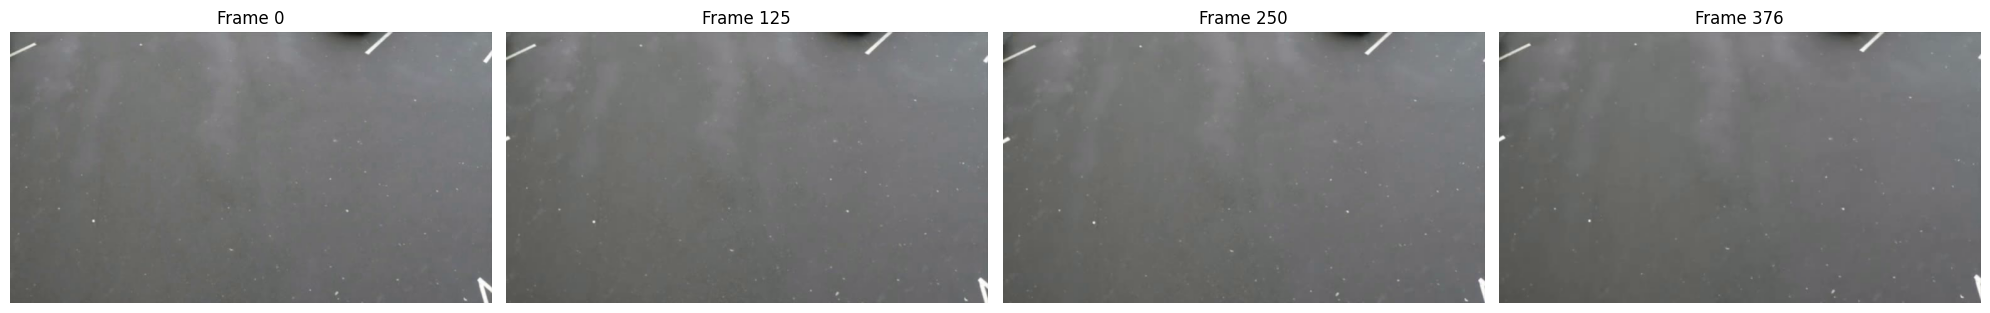

In [24]:
import glob


def display_frames_from_video(video_path: str, num_samples: int = 4) -> None:
    """Samples and displays frames from a video file using OpenCV.

    Args:
        video_path: Path to the (annotated) video file.
        num_samples: Number of evenly spaced frames to display.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Could not open video at '{video_path}'.")
        return

    try:
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        sample_indices = np.linspace(0, max(total_frames - 1, 0), num_samples, dtype=int)

        fig, axes = plt.subplots(1, num_samples, figsize=(5 * num_samples, 5))
        if num_samples == 1:
            axes = [axes]

        for ax, frame_idx in zip(axes, sample_indices):
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
            success, frame_bgr = cap.read()
            if not success:
                ax.axis("off")
                continue
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            ax.imshow(frame_rgb)
            ax.set_title(f"Frame {frame_idx}")
            ax.axis("off")

        plt.tight_layout()
        plt.show()
    finally:
        cap.release()


# Locate the most recently saved annotated video from the predict run.
try:
    predict_dirs = sorted(glob.glob("runs/detect/predict*"))
    if predict_dirs:
        annotated_videos = glob.glob(os.path.join(predict_dirs[-1], "*.mp4")) + \
                            glob.glob(os.path.join(predict_dirs[-1], "*.avi"))
        if annotated_videos:
            display_frames_from_video(annotated_videos[0], num_samples=4)
        else:
            print("No annotated video file found in the predict output directory.")
    else:
        print("No 'runs/detect/predict*' directory found. Run inference (Section 2.4) first.")
except Exception as exc:
    print(f"Could not display frames from the annotated video: {exc}")


## Summary

This notebook demonstrates two complementary computer vision competencies:

- **From-scratch architecture design & training:** a fully functional U-Net implemented with explicit control over channel counts, spatial dimensions, and skip connections -- validated with a shape-correctness test on arbitrary input sizes, trained end-to-end on a synthetic dataset with a combined BCE + Dice loss, and evaluated with IoU/Dice metrics and qualitative visualizations.
- **Applied transfer learning with a production library:** fine-tuning YOLOv8 on a benchmark dataset, visualizing its training curves, and deploying it for video inference with robust error handling, including practical visualization of the resulting detections.

Together, they illustrate both the underlying theory of segmentation networks and the ability to work efficiently and robustly with industry-standard detection tooling -- from architecture internals to production-style error handling.
